# Steane Circ Level Noise (single round)

Data generation and analysis
    + different decoder: ML, MWPM
    + different distances
    + different noise levels

analysis: 
    + show asymptotic behavior
    + determine thresholds


In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt

from tools.file import read_config, write_config, read_folder, get_standard_config
from tools.combined import generate_new_data_from_config_file
from tools.analysis import data_pre_processing, determine_threshold, data_plot_log_error_rates, data_plot_fssa_results

from tools.parameter import PATH_TO_CONFIG_FOLDER

## Config Defintions and Data Generation

Steane circ (order 0p) with only 1 QEC round (both log X and Z observable)

Circ noise with different noise levels

Decoding both in ML and MWPM


In [2]:
# General parameter
noise_rates = [float(x) for x in np.logspace(-1.9,-1,dtype=float)]
distances = [3,5,7,9,11,13,15] # 3 is newly included not yet in data
qec_rounds = [1,]
order = "0p"
circuit_type = "steane"
noise_model_type = "circ"

# Main parameters
num_shots_ML = 1_000
decoder_type_ML = "ml"
# 30 min
# 700 min + for 100_000 data
num_shots_MWPM = 10_000
decoder_type_MWPM = "mwpm"

# Z config
observable_Z  = "Z"
init_state_Z = "0"
# X config
observable_X  = "X"
init_state_X = "p"

In [3]:
# Folder names (for writing data to file):
w_folder_name_ML_Z = "circ_md_1r_steane_Z_ML"
w_folder_name_ML_X = "circ_md_1r_steane_X_ML"
w_folder_name_MWPM_Z = "circ_md_1r_steane_Z_MWPM"
w_folder_name_MWPM_X = "circ_md_1r_steane_X_MWPM"

In [4]:
# Switches for data generation
regen_data_everything = False 

regen_data_ML = False 
regen_data_MWPM = False 


In [5]:
# ML Config (Z)
# Verbose is better!
config_ML_Z = {
    "circuit": {
        "distances":    distances, 
        "qec_rounds":   qec_rounds, 
        "observable":   observable_Z,   
        # not yet implemented
        "order":        order, 
        "type":         circuit_type, 
        # redundant:
        "inital_state": init_state_Z,
        "special_parameter": {},
    },
    "noise_model": {
        "type":         noise_model_type,
        "noise_rates":  noise_rates,
        "special_parameter": {},        # open for future references
    },
    "decoder": {
        "type":         decoder_type_ML, 
    },
    "sampling": {
        "num_shots":    num_shots_ML,       # number of shots per configuration
    },
}
        
# write config to file
write_config(config_ML_Z,w_folder_name_ML_Z,backup=True)

In [6]:
# Generate ML Data
if regen_data_everything or regen_data_ML or False:
    config_path = os.path.join(PATH_TO_CONFIG_FOLDER, w_folder_name_ML_Z + ".yaml")
    generate_new_data_from_config_file(config_path,output_folder_name=w_folder_name_ML_Z)

In [7]:
# ML Config (X)

config_ML_X = {
    "circuit": {
        "distances":    distances, 
        "qec_rounds":   qec_rounds, 
        "observable":   observable_X,   
        # not yet implemented
        "order":        order, 
        "type":         circuit_type, 
        # redundant:
        "inital_state": init_state_X,
        "special_parameter": {},
    },
    "noise_model": {
        "type":         noise_model_type,
        "noise_rates":  noise_rates,
        "special_parameter": {},        # open for future references
    },
    "decoder": {
        "type":         decoder_type_ML, 
    },
    "sampling": {
        "num_shots":    num_shots_ML,       # number of shots per configuration
    },
}

# write config to file
write_config(config_ML_X,w_folder_name_ML_X,backup=True)

In [8]:
# Generate ML Data
if regen_data_everything or regen_data_ML or False:
    config_path = os.path.join(PATH_TO_CONFIG_FOLDER, w_folder_name_ML_X + ".yaml")
    generate_new_data_from_config_file(config_path,output_folder_name=w_folder_name_ML_X)

In [9]:
# MWPM Config (Z)

config_MWPM_Z = {
    "circuit": {
        "distances":    distances, 
        "qec_rounds":   qec_rounds, 
        "observable":   observable_Z,   
        # not yet implemented
        "order":        order, 
        "type":         circuit_type, 
        # redundant:
        "inital_state": init_state_Z,
        "special_parameter": {},
    },
    "noise_model": {
        "type":         noise_model_type,
        "noise_rates":  noise_rates,
        "special_parameter": {},        # open for future references
    },
    "decoder": {
        "type":         decoder_type_MWPM, 
    },
    "sampling": {
        "num_shots":    num_shots_MWPM,       # number of shots per configuration
    },
}

# write config to file
write_config(config_MWPM_Z,w_folder_name_MWPM_Z,backup=True)

In [10]:
# Generate MWPM data
if regen_data_everything or regen_data_MWPM or False:
    config_path = os.path.join(PATH_TO_CONFIG_FOLDER, w_folder_name_MWPM_Z + ".yaml")
    generate_new_data_from_config_file(config_path,output_folder_name=w_folder_name_MWPM_Z)

In [11]:
# MWPM Config (X)

config_MWPM_X = {
    "circuit": {
        "distances":    distances, 
        "qec_rounds":   qec_rounds, 
        "observable":   observable_X,   
        # not yet implemented
        "order":        order, 
        "type":         circuit_type, 
        # redundant:
        "inital_state": init_state_X,
        "special_parameter": {},
    },
    "noise_model": {
        "type":         noise_model_type,
        "noise_rates":  noise_rates,
        "special_parameter": {},        # open for future references
    },
    "decoder": {
        "type":         decoder_type_MWPM, 
    },
    "sampling": {
        "num_shots":    num_shots_MWPM,     
    },
}

# write config to file
write_config(config_MWPM_X,w_folder_name_MWPM_X,backup=True)

In [12]:
# Generate MWPM data
if regen_data_everything or regen_data_MWPM or False:
    config_path = os.path.join(PATH_TO_CONFIG_FOLDER, w_folder_name_MWPM_X + ".yaml")
    generate_new_data_from_config_file(config_path,output_folder_name=w_folder_name_MWPM_X)

# Analysis

In [13]:
# Folder paths (reading in data)
r_folder_name_ML_Z = "circ_md_1r_steane_Z_ML"
r_folder_name_ML_X = "circ_md_1r_steane_X_ML"
r_folder_name_MWPM_Z = "circ_md_1r_steane_Z_MWPM"
r_folder_name_MWPM_X = "circ_md_1r_steane_X_MWPM"


In [14]:
def analysis_pipeline(
        folder_name, 
        guess_pth, 
        guess_nu, 
        min_distance: list = [0]*100, # hacky but each round can get their own min distance!
        min_noise_rate: list = [0]*100,
        max_noise_rate: list = [1]*100,
        p_window: list = [1]*100,
        plots = True,
        ):

    if p_window != [1]*100:
        if min_noise_rate != [0]*100 or max_noise_rate != [1]*100:
            raise UserWarning("Both p_window and min-/max_noise_rate give! Too much restictions!")
        min_noise_rate = np.array(guess_pth) / p_window,
        max_noise_rate = np.array(guess_pth) * p_window,

    print(min_noise_rate)
    print(max_noise_rate)
    config, data = read_folder(folder_name)
    data = data_pre_processing(data)
    data = determine_threshold(
        data,
        guess_nu=guess_nu,
        guess_pth=guess_pth,
        min_distance=min_distance,
        min_noise_rate=min_noise_rate,
        max_noise_rate=max_noise_rate,
        )
    # complete
    if plots:
        data_plot_log_error_rates(data)
        data_plot_fssa_results(
            data,
            min_distance=min_distance,
            min_noise_rate=min_noise_rate,
            max_noise_rate=max_noise_rate,
            )
        # around threshold
        data_plot_log_error_rates(
            data,
            min_distance=min_distance,
            min_noise_rate=min_noise_rate,
            max_noise_rate=max_noise_rate,
        )
    return data

### Generate analysis Data

In [15]:
# General fit parameters: 
g_pth_ml = 0.03
g_pth_mwpm = 0.03

g_nu = 1.5

p_window = [10**(0.2)]
min_distance = [5]

(array([0.01892872]),)
(array([0.0475468]),)

       message: Optimization terminated successfully.
       success: True
        status: 0
           fun: 0.9363561113035235
             x: [ 3.050e-02  6.077e-01]
           nit: 59
          nfev: 113
 final_simplex: (array([[ 3.050e-02,  6.077e-01],
                       [ 3.050e-02,  6.077e-01],
                       [ 3.050e-02,  6.077e-01]]), array([ 9.364e-01,  9.364e-01,  9.364e-01]))
[0.03049974]
[0.00382945]


<Figure size 640x480 with 0 Axes>

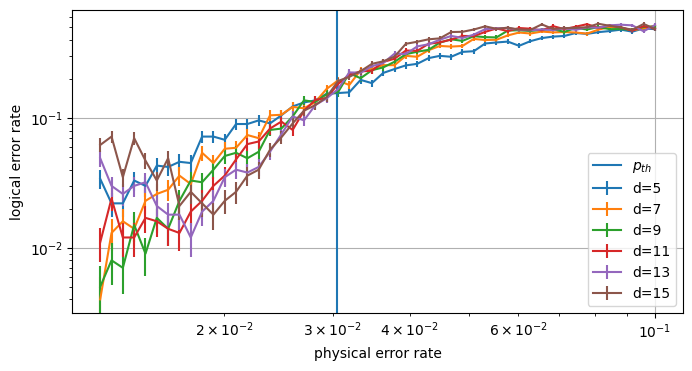

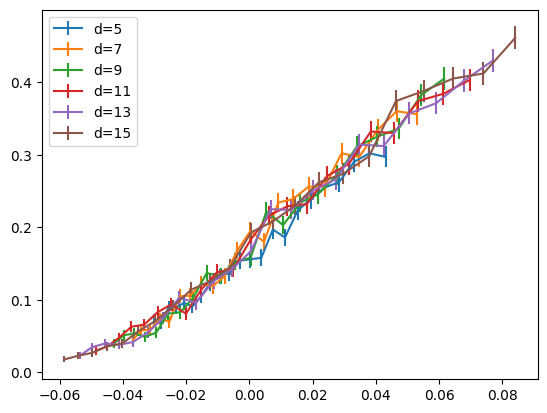

<Figure size 640x480 with 0 Axes>

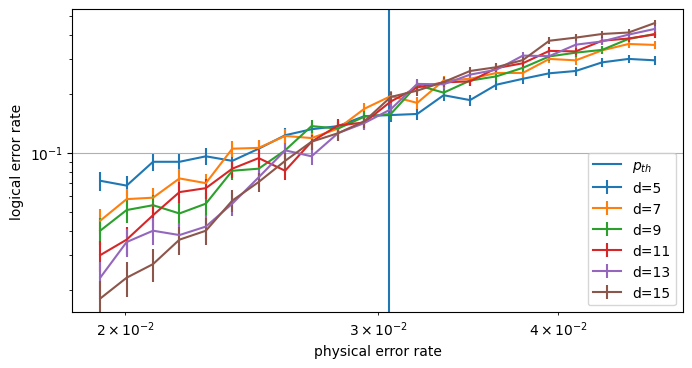

[0.03049974]
[1.64542235]


In [16]:
folder_name = r_folder_name_ML_Z
g_pth = g_pth_ml

result = analysis_pipeline(
    folder_name,
    guess_pth = [g_pth],
    guess_nu = [g_nu],
    min_distance= min_distance, 
    p_window = p_window,
    )

print(result["p_th"])
print(result["nu_fit"])
results_ML_Z = result

(array([0.01892872]),)
(array([0.0475468]),)

       message: Optimization terminated successfully.
       success: True
        status: 0
           fun: 1.3021441565231406
             x: [ 3.481e-02  6.419e-01]
           nit: 47
          nfev: 92
 final_simplex: (array([[ 3.481e-02,  6.419e-01],
                       [ 3.481e-02,  6.419e-01],
                       [ 3.481e-02,  6.419e-01]]), array([ 1.302e+00,  1.302e+00,  1.302e+00]))
[0.03480558]
[0.00600805]


<Figure size 640x480 with 0 Axes>

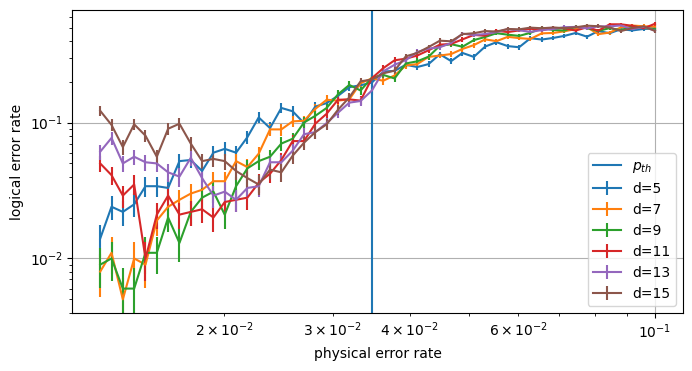

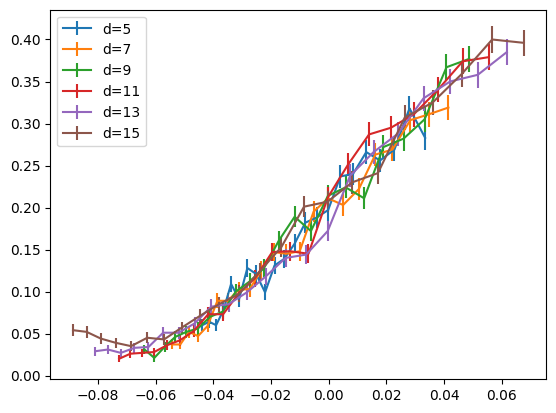

<Figure size 640x480 with 0 Axes>

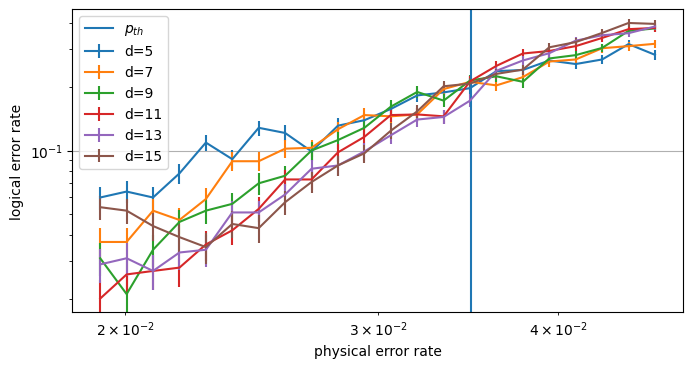

[0.03480558]
[1.55794152]


In [17]:
folder_name = r_folder_name_ML_X 
g_pth = g_pth_ml 

result = analysis_pipeline(
    folder_name = folder_name,
    guess_pth = [g_pth],
    guess_nu = [g_nu],
    min_distance= min_distance, 
    p_window = p_window,
    )

print(result["p_th"])
print(result["nu_fit"])
results_ML_X = result

(array([0.01892872]),)
(array([0.0475468]),)

       message: Optimization terminated successfully.
       success: True
        status: 0
           fun: 0.9965077970205755
             x: [ 2.722e-02  7.190e-01]
           nit: 51
          nfev: 96
 final_simplex: (array([[ 2.722e-02,  7.190e-01],
                       [ 2.722e-02,  7.190e-01],
                       [ 2.722e-02,  7.190e-01]]), array([ 9.965e-01,  9.965e-01,  9.965e-01]))
[0.02721579]
[0.00066515]


<Figure size 640x480 with 0 Axes>

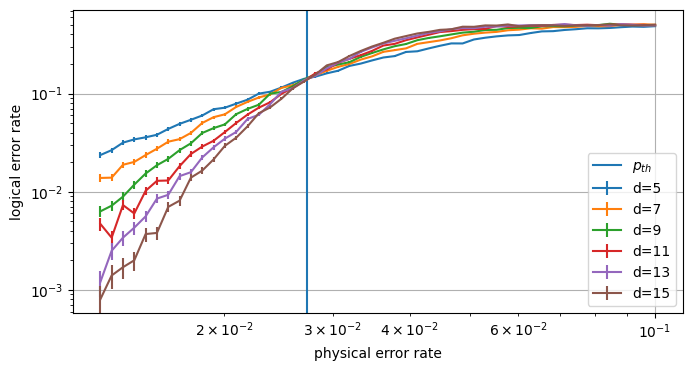

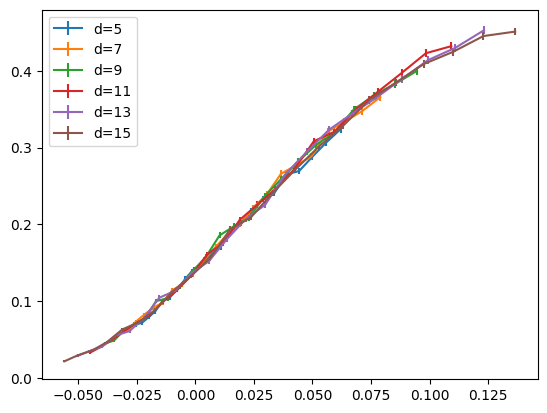

<Figure size 640x480 with 0 Axes>

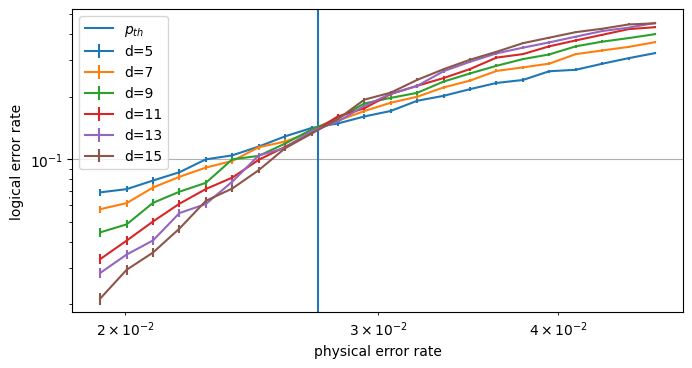

[0.02721579]
[1.39081512]


In [18]:
folder_name = r_folder_name_MWPM_Z 
g_pth = g_pth_mwpm 

result = analysis_pipeline(
    folder_name = folder_name,
    guess_pth = [g_pth],
    guess_nu = [g_nu],
    min_distance= min_distance, 
    p_window =  p_window,
    )

print(result["p_th"])
print(result["nu_fit"])
results_MWPM_Z= result

(array([0.01892872]),)
(array([0.0475468]),)

       message: Optimization terminated successfully.
       success: True
        status: 0
           fun: 1.1597131004668753
             x: [ 3.231e-02  6.672e-01]
           nit: 57
          nfev: 111
 final_simplex: (array([[ 3.231e-02,  6.672e-01],
                       [ 3.231e-02,  6.672e-01],
                       [ 3.231e-02,  6.672e-01]]), array([ 1.160e+00,  1.160e+00,  1.160e+00]))
[0.0323052]
[0.00096677]


<Figure size 640x480 with 0 Axes>

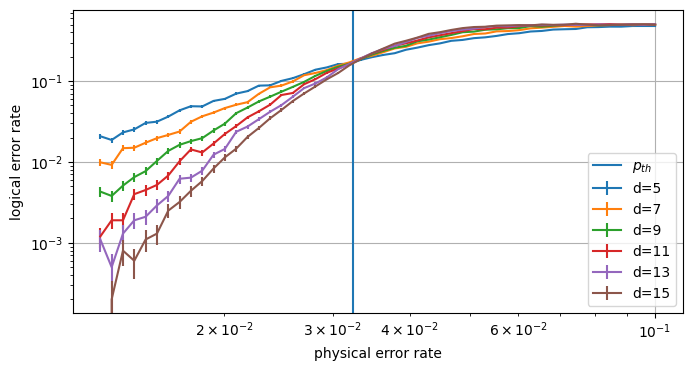

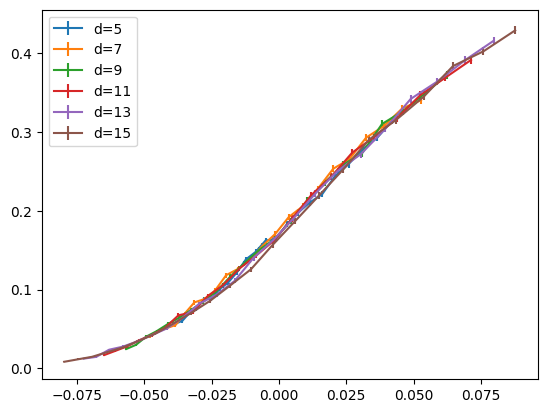

<Figure size 640x480 with 0 Axes>

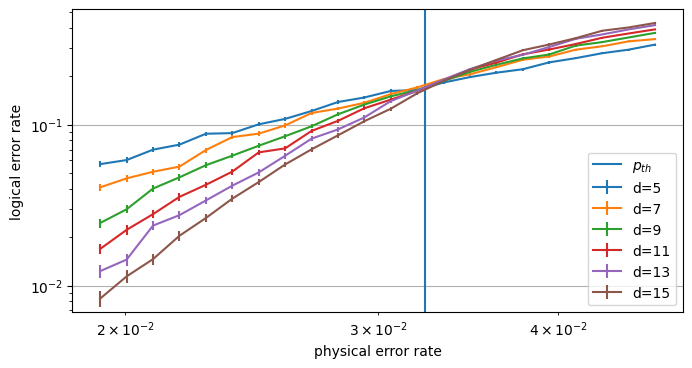

[0.0323052]
[1.49884052]


In [19]:
folder_name = r_folder_name_MWPM_X 
g_pth = g_pth_mwpm 

result = analysis_pipeline(
    folder_name = folder_name,
    guess_pth = [g_pth],
    guess_nu = [g_nu],
    min_distance= min_distance, 
    p_window =  p_window,
    )

print(result["p_th"])
print(result["nu_fit"])
results_MWPM_X = result

## Thresholds Results (1 round circ noise)

In [20]:
# collection of all threshold:
results = [results_ML_Z, results_ML_X, results_MWPM_Z, results_MWPM_X]
names = ["ML Z", "ML X", "MWPM Z", "MWPM X"]

for i in range(len(names)):
    print(f"For {names[i]}: threshold = {results[i]["p_th"][0]*10**2:.3f} +- {results[i]["err_p_th"][0]*10**2:.3f}") 



For ML Z: threshold = 3.050 +- 0.383
For ML X: threshold = 3.481 +- 0.601
For MWPM Z: threshold = 2.722 +- 0.067
For MWPM X: threshold = 3.231 +- 0.097


X error Threshold seems to be higher. 
Does this fit expectation? 

Z errors corrected first => more not tracked errors introduce by circ noise => residual error is higher => fits expectations.

## Varying parameters

In [21]:


# as collections
folder_names = [r_folder_name_ML_Z, r_folder_name_ML_X, r_folder_name_MWPM_Z, r_folder_name_MWPM_X]
names = ["ML Z", "ML X", "MWPM Z", "MWPM X"]

g_pths = [g_pth_ml] *2  + [g_pth_mwpm]*2

g_nus = [g_nu] * 4

In [22]:
# Varying distance
min_distances = [5,7,9,11,13]

p_th_varied = np.zeros((len(min_distances), len(folder_names)))
err_p_th_varied = np.zeros((len(min_distances), len(folder_names)))
nu_fit_varied = np.zeros((len(min_distances), len(folder_names))) 

for j in range(len(min_distances)):
    for i in range(len(folder_names)):
        result = analysis_pipeline(
            folder_name = folder_names[i],
            guess_pth = [g_pths[i]],
            guess_nu = [g_nus[i]],
            min_distance= [min_distances[j]], 
            p_window= p_window,
            plots=False,
            )

        p_th_varied[j,i] =  result["p_th"][0]
        err_p_th_varied[j,i] =  result["err_p_th"][0]
        nu_fit_varied[j,i] = result["nu_fit"][0]

(array([0.01892872]),)
(array([0.0475468]),)

       message: Optimization terminated successfully.
       success: True
        status: 0
           fun: 0.9363561113035235
             x: [ 3.050e-02  6.077e-01]
           nit: 59
          nfev: 113
 final_simplex: (array([[ 3.050e-02,  6.077e-01],
                       [ 3.050e-02,  6.077e-01],
                       [ 3.050e-02,  6.077e-01]]), array([ 9.364e-01,  9.364e-01,  9.364e-01]))
[0.03049974]
[0.00351645]
(array([0.01892872]),)
(array([0.0475468]),)

       message: Optimization terminated successfully.
       success: True
        status: 0
           fun: 1.3021441565231406
             x: [ 3.481e-02  6.419e-01]
           nit: 47
          nfev: 92
 final_simplex: (array([[ 3.481e-02,  6.419e-01],
                       [ 3.481e-02,  6.419e-01],
                       [ 3.481e-02,  6.419e-01]]), array([ 1.302e+00,  1.302e+00,  1.302e+00]))
[0.03480558]
[0.00641684]
(array([0.01892872]),)
(array([0.0475468]),)

       

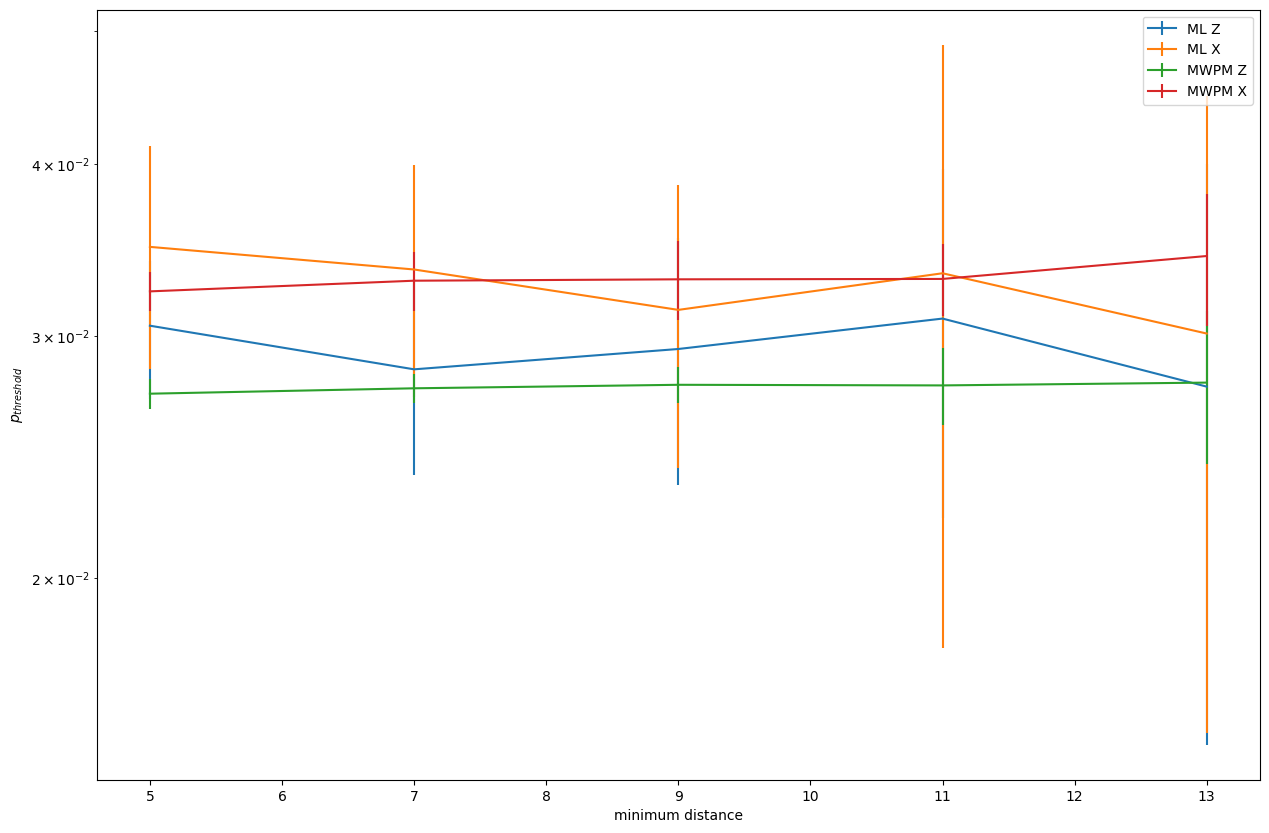

In [23]:
plt.figure(figsize=(15,10))
plt.xlabel("minimum distance")
for i in range(len(folder_names)):
    plt.errorbar(min_distances,p_th_varied[:,i], yerr=err_p_th_varied[:,i],label=names[i])
plt.ylabel("$p_{threshold}$")
plt.yscale("log")
plt.legend()
plt.show()